In [2]:
# ============================================
# CONFIGURATION — ADJUST THRESHOLDS HERE ONLY
# ============================================
# TODO: Replace with INRAT's actual growth-curve-based thresholds 
#       once confirmed with supervisor

CLOUD_THRESHOLD_DELETE = 80          # above this = delete (image too obstructed)
CLOUD_THRESHOLD_INTERPOLATE = 8      # between this and DELETE = interpolate
                                       # below this = flag for review

print("Current thresholds loaded:")
print(f"  Delete if cloud cover > {CLOUD_THRESHOLD_DELETE}%")
print(f"  Interpolate if cloud cover between {CLOUD_THRESHOLD_INTERPOLATE}% and {CLOUD_THRESHOLD_DELETE}%")
print(f"  Flag if cloud cover < {CLOUD_THRESHOLD_INTERPOLATE}% but data still missing")

Current thresholds loaded:
  Delete if cloud cover > 80%
  Interpolate if cloud cover between 8% and 80%
  Flag if cloud cover < 8% but data still missing


In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/master_beja.csv")
print(f"Loaded {len(df)} rows")
df.head()

Loaded 696 rows


,Date,Nuages_%,NDVI,EVI,NDRE,GNDVI,SAVI,variety,source_file
0,2024-11-03,1.23,0.164440,0.075329,0.082779,0.277472,0.082654,carioka,indices_nuages_carioka.csv
1,2024-11-08,12.33,0.186800,0.089692,0.100240,0.317070,0.099258,carioka,indices_nuages_carioka.csv
2,2024-11-13,2.22,0.214849,0.097429,0.109707,0.327559,0.109638,carioka,indices_nuages_carioka.csv
3,2024-11-23,10.94,0.280921,0.126662,0.153942,0.368445,0.139012,carioka,indices_nuages_carioka.csv
4,2024-11-28,17.39,0.038489,0.199998,0.013696,0.031475,0.039936,carioka,indices_nuages_carioka.csv


In [4]:
missing_mask = df['NDVI'].isna()
missing_rows = df[missing_mask]

print(f"Total missing rows in corrected dataset: {len(missing_rows)}")
print()
print("Missing rows per variety:")
print(missing_rows['variety'].value_counts())
print()
print("Cloud cover values for these missing rows:")
print(missing_rows['Nuages_%'].describe())

Total missing rows in corrected dataset: 41

Missing rows per variety:
variety
khiar       11
dhahbi      10
maali        6
salim        5
inrat100     3
karim        3
carioka      2
saragola     1
Name: count, dtype: int64

Cloud cover values for these missing rows:
count    41.000000
mean     10.615366
std       4.670578
min       4.460000
25%       7.380000
50%       7.380000
75%      14.910000
max      19.530000
Name: Nuages_%, dtype: float64


In [5]:
from scipy import stats

cloud_missing = df[missing_mask]['Nuages_%'].dropna()
cloud_present = df[~missing_mask]['Nuages_%'].dropna()

t_stat, p_value = stats.ttest_ind(cloud_missing, cloud_present)

print(f"Average cloud cover when NDVI is present: {cloud_present.mean():.2f}%")
print(f"Average cloud cover when NDVI is missing: {cloud_missing.mean():.2f}%")
print(f"P-value: {p_value:.6f}")

Average cloud cover when NDVI is present: 4.89%
Average cloud cover when NDVI is missing: 10.62%
P-value: 0.000000


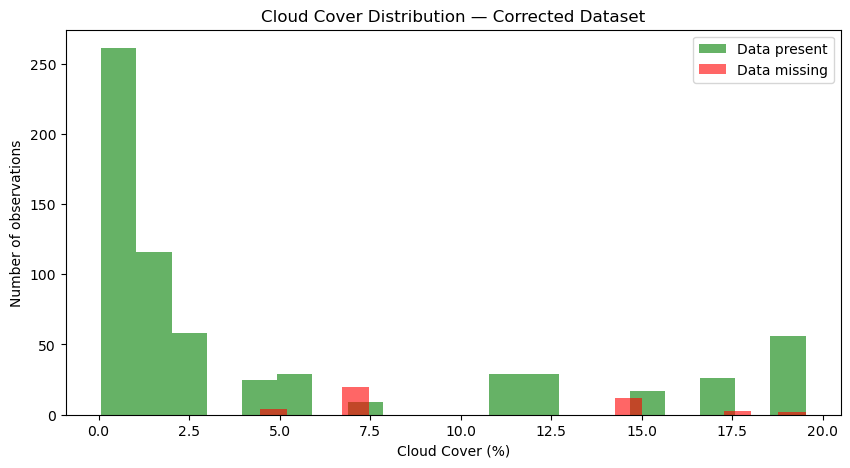

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df[~missing_mask]['Nuages_%'].dropna(), bins=20, alpha=0.6, color='green', label='Data present')
plt.hist(df[missing_mask]['Nuages_%'].dropna(), bins=20, alpha=0.6, color='red', label='Data missing')
plt.xlabel('Cloud Cover (%)')
plt.ylabel('Number of observations')
plt.title('Cloud Cover Distribution — Corrected Dataset')
plt.legend()
plt.show()

In [7]:
def decide_action(cloud_pct):
    """
    Decides what to do with a missing vegetation index value,
    based on the cloud cover percentage for that observation.
    """
    if cloud_pct > CLOUD_THRESHOLD_DELETE:
        return "DELETE"
    elif cloud_pct >= CLOUD_THRESHOLD_INTERPOLATE:
        return "INTERPOLATE"
    else:
        return "FLAG"

# quick test before applying it to real data
print(decide_action(85))   # should print DELETE
print(decide_action(50))   # should print INTERPOLATE
print(decide_action(5))    # should print FLAG

DELETE
INTERPOLATE
FLAG


In [8]:
# get the cloud cover values for just the missing rows
missing_rows = df[missing_mask].copy()

# apply our function to every row's cloud cover value
missing_rows['decision'] = missing_rows['Nuages_%'].apply(decide_action)

print(missing_rows['decision'].value_counts())
print()
print(missing_rows[['Date', 'variety', 'Nuages_%', 'decision']].to_string())

decision
FLAG           24
INTERPOLATE    17
Name: count, dtype: int64

           Date   variety  Nuages_%     decision
11   2025-03-18   carioka      7.38         FLAG
12   2025-04-04   carioka     14.91  INTERPOLATE
35   2025-03-18    dhahbi      7.38         FLAG
56   2025-01-07    dhahbi      4.46         FLAG
59   2025-03-18    dhahbi      7.38         FLAG
80   2025-01-07    dhahbi      4.46         FLAG
83   2025-03-18    dhahbi      7.38         FLAG
107  2025-03-18    dhahbi      7.38         FLAG
125  2024-12-13    dhahbi     19.17  INTERPOLATE
126  2024-12-13    dhahbi     19.53  INTERPOLATE
131  2025-03-18    dhahbi      7.38         FLAG
155  2025-03-18    dhahbi      7.38         FLAG
180  2025-04-04  inrat100     14.91  INTERPOLATE
204  2025-04-04  inrat100     14.91  INTERPOLATE
228  2025-04-04  inrat100     14.91  INTERPOLATE
252  2025-04-04     karim     14.91  INTERPOLATE
275  2025-03-18     karim      7.38         FLAG
276  2025-04-04     karim     14.91  INTERPOLA

In [9]:
# sort by variety first, then by date within each variety
df_sorted = df.sort_values(by=['variety', 'Date']).reset_index(drop=True)
df_sorted.head(10)

,Date,Nuages_%,NDVI,EVI,NDRE,GNDVI,SAVI,variety,source_file
0,2024-11-03,1.23,0.164440,0.075329,0.082779,0.277472,0.082654,carioka,indices_nuages_carioka.csv
1,2024-11-08,12.33,0.186800,0.089692,0.100240,0.317070,0.099258,carioka,indices_nuages_carioka.csv
2,2024-11-13,2.22,0.214849,0.097429,0.109707,0.327559,0.109638,carioka,indices_nuages_carioka.csv
3,2024-11-23,10.94,0.280921,0.126662,0.153942,0.368445,0.139012,carioka,indices_nuages_carioka.csv
4,2024-11-28,17.39,0.038489,0.199998,0.013696,0.031475,0.039936,carioka,indices_nuages_carioka.csv
5,2024-12-13,19.17,0.256029,0.123202,0.150772,0.313238,0.123320,carioka,indices_nuages_carioka.csv
6,2024-12-13,19.53,0.230708,0.118215,0.123815,0.299161,0.119952,carioka,indices_nuages_carioka.csv
7,2024-12-18,0.73,0.324450,0.149755,0.199906,0.396308,0.161513,carioka,indices_nuages_carioka.csv
8,2025-01-07,4.46,0.452306,0.278301,0.284404,0.454198,0.270334,carioka,indices_nuages_carioka.csv
9,2025-02-16,1.82,0.718500,0.512610,0.525553,0.661409,0.472266,carioka,indices_nuages_carioka.csv


In [10]:
duplicate_dates = df_sorted[df_sorted.duplicated(subset=['variety', 'Date'], keep=False)]
print(f"Number of rows involved in duplicate dates: {len(duplicate_dates)}")
print(duplicate_dates[['Date', 'variety', 'Nuages_%', 'NDVI']].to_string())

Number of rows involved in duplicate dates: 630
           Date   variety  Nuages_%      NDVI
5    2024-12-13   carioka     19.17  0.256029
6    2024-12-13   carioka     19.53  0.230708
24   2024-11-03    dhahbi      1.23  0.165707
25   2024-11-03    dhahbi      1.23  0.204914
26   2024-11-03    dhahbi      1.23  0.195042
27   2024-11-03    dhahbi      1.23  0.191437
28   2024-11-03    dhahbi      1.23  0.200062
29   2024-11-03    dhahbi      1.23  0.176793
30   2024-11-08    dhahbi     12.33  0.200907
31   2024-11-08    dhahbi     12.33  0.229661
32   2024-11-08    dhahbi     12.33  0.219528
33   2024-11-08    dhahbi     12.33  0.218360
34   2024-11-08    dhahbi     12.33  0.182287
35   2024-11-08    dhahbi     12.33  0.176418
36   2024-11-13    dhahbi      2.22  0.213878
37   2024-11-13    dhahbi      2.22  0.250966
38   2024-11-13    dhahbi      2.22  0.240684
39   2024-11-13    dhahbi      2.22  0.228439
40   2024-11-13    dhahbi      2.22  0.198246
41   2024-11-13    dhahbi      2

In [11]:
# check: within ONE source file, are dates unique?
one_file = df_sorted[df_sorted['source_file'] == 'indices_nuages_dhahbi2.csv']
print(f"Rows in this file: {len(one_file)}")
print(f"Unique dates in this file: {one_file['Date'].nunique()}")
print(one_file[['Date', 'Nuages_%', 'NDVI']].to_string())

Rows in this file: 24
Unique dates in this file: 23
           Date  Nuages_%      NDVI
24   2024-11-03      1.23  0.165707
30   2024-11-08     12.33  0.200907
36   2024-11-13      2.22  0.213878
42   2024-11-23     10.94  0.243365
48   2024-11-28     17.39  0.201541
54   2024-12-13     19.17  0.240056
55   2024-12-13     19.53  0.226526
66   2024-12-18      0.73  0.311742
72   2025-01-07      4.46  0.435608
78   2025-02-16      1.82  0.915780
84   2025-03-15      1.78  0.864951
90   2025-03-18      7.38       NaN
96   2025-04-04     14.91  0.930589
102  2025-05-02      2.93  0.823715
108  2025-05-17      4.94  0.309971
114  2025-05-27      1.97  0.197832
120  2025-06-01      0.14  0.187815
126  2025-06-03      0.46  0.180760
132  2025-06-11      0.36  0.173459
138  2025-06-13      0.11  0.188881
144  2025-06-16      0.09  0.165252
150  2025-06-21      0.24  0.166401
156  2025-06-23      0.15  0.167326
162  2025-06-26      0.07  0.162889


In [12]:
# sort by source_file first, then by date within each file
df_sorted = df.sort_values(by=['source_file', 'Date']).reset_index(drop=True)

# verify: check unique dates per file
print(df_sorted.groupby('source_file')['Date'].nunique())
print()
print(df_sorted.groupby('source_file').size())

source_file
indices_nuages_carioka.csv       23
indices_nuages_dhahbi2.csv       23
indices_nuages_dhahbi3.csv       23
indices_nuages_dhahbi4.csv       23
indices_nuages_dhahbi5.csv       23
indices_nuages_dhahbi6.csv       23
indices_nuages_dhahbi7.csv       23
indices_nuages_inrat100.csv      23
indices_nuages_inrat100_1.csv    23
indices_nuages_inrat100_2.csv    23
indices_nuages_karim.csv         23
indices_nuages_karim1.csv        23
indices_nuages_khiar.csv         23
indices_nuages_khiar1.csv        23
indices_nuages_khiar2.csv        23
indices_nuages_khiar3.csv        23
indices_nuages_khiar4.csv        23
indices_nuages_khiar5.csv        23
indices_nuages_maali0.csv        23
indices_nuages_maali1.csv        23
indices_nuages_maali2.csv        23
indices_nuages_maali3.csv        23
indices_nuages_maali4.csv        23
indices_nuages_maali5.csv        23
indices_nuages_salim.csv         23
indices_nuages_salim1.csv        23
indices_nuages_salim2.csv        23
indices_nuages_s

In [13]:
# group by source_file AND date, average any duplicates
df_deduped = df_sorted.groupby(['source_file', 'variety', 'Date'], as_index=False).agg({
    'Nuages_%': 'mean',
    'NDVI': 'mean',
    'EVI': 'mean',
    'NDRE': 'mean',
    'GNDVI': 'mean',
    'SAVI': 'mean'
})

print(f"Rows before dedup: {len(df_sorted)}")
print(f"Rows after dedup: {len(df_deduped)}")
print()
print(df_deduped.groupby('source_file').size())

Rows before dedup: 696
Rows after dedup: 667

source_file
indices_nuages_carioka.csv       23
indices_nuages_dhahbi2.csv       23
indices_nuages_dhahbi3.csv       23
indices_nuages_dhahbi4.csv       23
indices_nuages_dhahbi5.csv       23
indices_nuages_dhahbi6.csv       23
indices_nuages_dhahbi7.csv       23
indices_nuages_inrat100.csv      23
indices_nuages_inrat100_1.csv    23
indices_nuages_inrat100_2.csv    23
indices_nuages_karim.csv         23
indices_nuages_karim1.csv        23
indices_nuages_khiar.csv         23
indices_nuages_khiar1.csv        23
indices_nuages_khiar2.csv        23
indices_nuages_khiar3.csv        23
indices_nuages_khiar4.csv        23
indices_nuages_khiar5.csv        23
indices_nuages_maali0.csv        23
indices_nuages_maali1.csv        23
indices_nuages_maali2.csv        23
indices_nuages_maali3.csv        23
indices_nuages_maali4.csv        23
indices_nuages_maali5.csv        23
indices_nuages_salim.csv         23
indices_nuages_salim1.csv        23
indice

In [14]:
print(df_deduped.dtypes)
print()
print(df_deduped[df_deduped['source_file'] == 'indices_nuages_dhahbi2.csv'][['Date', 'Nuages_%', 'NDVI']].to_string())

source_file     object
variety         object
Date            object
Nuages_%       float64
NDVI           float64
EVI            float64
NDRE           float64
GNDVI          float64
SAVI           float64
dtype: object

          Date  Nuages_%      NDVI
23  2024-11-03      1.23  0.165707
24  2024-11-08     12.33  0.200907
25  2024-11-13      2.22  0.213878
26  2024-11-23     10.94  0.243365
27  2024-11-28     17.39  0.201541
28  2024-12-13     19.35  0.233291
29  2024-12-18      0.73  0.311742
30  2025-01-07      4.46  0.435608
31  2025-02-16      1.82  0.915780
32  2025-03-15      1.78  0.864951
33  2025-03-18      7.38       NaN
34  2025-04-04     14.91  0.930589
35  2025-05-02      2.93  0.823715
36  2025-05-17      4.94  0.309971
37  2025-05-27      1.97  0.197832
38  2025-06-01      0.14  0.187815
39  2025-06-03      0.46  0.180760
40  2025-06-11      0.36  0.173459
41  2025-06-13      0.11  0.188881
42  2025-06-16      0.09  0.165252
43  2025-06-21      0.24  0.166401
44  2025

In [15]:
df_deduped['Date'] = pd.to_datetime(df_deduped['Date'], format='mixed')
print(df_deduped['Date'].dtype)
print(df_deduped[['Date']].head())

datetime64[ns]
        Date
0 2024-11-03
1 2024-11-08
2 2024-11-13
3 2024-11-23
4 2024-11-28


In [16]:
print(df_deduped['Date'].dtype)
print(df_deduped[['Date']].head(10))

datetime64[ns]
        Date
0 2024-11-03
1 2024-11-08
2 2024-11-13
3 2024-11-23
4 2024-11-28
5 2024-12-13
6 2024-12-18
7 2025-01-07
8 2025-02-16
9 2025-03-15


In [17]:
df_deduped = df_deduped.sort_values(by=['source_file', 'Date']).reset_index(drop=True)

index_cols = ['NDVI', 'EVI', 'NDRE', 'GNDVI', 'SAVI']

def interpolate_file(group):
    group = group.set_index('Date')
    group[index_cols] = group[index_cols].interpolate(method='time')
    group = group.reset_index()
    return group

df_interpolated = df_deduped.groupby('source_file', group_keys=True).apply(interpolate_file, include_groups=False)
df_interpolated = df_interpolated.reset_index(level=0)      # restores 'source_file' as a column
df_interpolated = df_interpolated.reset_index(drop=True)    # cleans up leftover numeric index

print(f"Missing NDVI before interpolation: {df_deduped['NDVI'].isna().sum()}")
print(f"Missing NDVI after interpolation: {df_interpolated['NDVI'].isna().sum()}")

Missing NDVI before interpolation: 40
Missing NDVI after interpolation: 0


In [18]:
# look at dhahbi2's full timeline, including the interpolated value
check = df_interpolated[df_interpolated['source_file'] == 'indices_nuages_dhahbi2.csv']
print(check[['Date', 'Nuages_%', 'NDVI']].to_string())

         Date  Nuages_%      NDVI
23 2024-11-03      1.23  0.165707
24 2024-11-08     12.33  0.200907
25 2024-11-13      2.22  0.213878
26 2024-11-23     10.94  0.243365
27 2024-11-28     17.39  0.201541
28 2024-12-13     19.35  0.233291
29 2024-12-18      0.73  0.311742
30 2025-01-07      4.46  0.435608
31 2025-02-16      1.82  0.915780
32 2025-03-15      1.78  0.864951
33 2025-03-18      7.38  0.874796
34 2025-04-04     14.91  0.930589
35 2025-05-02      2.93  0.823715
36 2025-05-17      4.94  0.309971
37 2025-05-27      1.97  0.197832
38 2025-06-01      0.14  0.187815
39 2025-06-03      0.46  0.180760
40 2025-06-11      0.36  0.173459
41 2025-06-13      0.11  0.188881
42 2025-06-16      0.09  0.165252
43 2025-06-21      0.24  0.166401
44 2025-06-23      0.15  0.167326
45 2025-06-26      0.07  0.162889


In [19]:
# Start fresh from the deduplicated, properly-dated data (before interpolation)
df_work = df_deduped.copy()

# Track which rows were originally missing, before we touch anything
originally_missing = df_work['NDVI'].isna()

# Apply decision logic to ALL rows (decision only matters for missing ones,
# but we calculate it for everyone so we have it available)
df_work['decision'] = df_work['Nuages_%'].apply(decide_action)

# Build the audit log: one entry per originally-missing row
audit_log = []

for idx in df_work[originally_missing].index:
    row = df_work.loc[idx]
    audit_log.append({
        'source_file': row['source_file'],
        'variety': row['variety'],
        'date': row['Date'],
        'cloud_cover': row['Nuages_%'],
        'decision': row['decision']
    })

audit_df = pd.DataFrame(audit_log)
print(audit_df['decision'].value_counts())
print()
print(audit_df.to_string())

decision
FLAG           24
INTERPOLATE    16
Name: count, dtype: int64

                      source_file   variety       date  cloud_cover     decision
0      indices_nuages_carioka.csv   carioka 2025-03-18         7.38         FLAG
1      indices_nuages_carioka.csv   carioka 2025-04-04        14.91  INTERPOLATE
2      indices_nuages_dhahbi2.csv    dhahbi 2025-03-18         7.38         FLAG
3      indices_nuages_dhahbi3.csv    dhahbi 2025-01-07         4.46         FLAG
4      indices_nuages_dhahbi3.csv    dhahbi 2025-03-18         7.38         FLAG
5      indices_nuages_dhahbi4.csv    dhahbi 2025-01-07         4.46         FLAG
6      indices_nuages_dhahbi4.csv    dhahbi 2025-03-18         7.38         FLAG
7      indices_nuages_dhahbi5.csv    dhahbi 2025-03-18         7.38         FLAG
8      indices_nuages_dhahbi6.csv    dhahbi 2024-12-13        19.35  INTERPOLATE
9      indices_nuages_dhahbi6.csv    dhahbi 2025-03-18         7.38         FLAG
10     indices_nuages_dhahbi7.csv    

In [20]:
df_final = df_deduped.copy()
df_final = df_final.sort_values(by=['source_file', 'Date']).reset_index(drop=True)

index_cols = ['NDVI', 'EVI', 'NDRE', 'GNDVI', 'SAVI']

def interpolate_file(group):
    group = group.set_index('Date')
    group[index_cols] = group[index_cols].interpolate(method='time')
    group = group.reset_index()
    return group

df_final = df_final.groupby('source_file', group_keys=True).apply(interpolate_file, include_groups=False)
df_final = df_final.reset_index(level=0)      # restores 'source_file' as a column
df_final = df_final.reset_index(drop=True)    # cleans up leftover numeric index

df_final['decision'] = None
df_final['was_originally_missing'] = originally_missing.values

rows_to_delete = []

for idx in df_final[df_final['was_originally_missing']].index:
    cloud_pct = df_final.loc[idx, 'Nuages_%']
    decision = decide_action(cloud_pct)
    df_final.loc[idx, 'decision'] = decision
    
    if decision == 'DELETE':
        rows_to_delete.append(idx)
    elif decision == 'FLAG':
        df_final.loc[idx, index_cols] = np.nan

df_final = df_final.drop(index=rows_to_delete).reset_index(drop=True)

print(f"Rows deleted: {len(rows_to_delete)}")
print(f"Total rows remaining: {len(df_final)}")
print(f"Still missing (flagged): {df_final['NDVI'].isna().sum()}")

Rows deleted: 0
Total rows remaining: 667
Still missing (flagged): 24


In [21]:
df_final = df_final.groupby('source_file', group_keys=True).apply(interpolate_file, include_groups=False)
df_final = df_final.reset_index(level=0)      # restores 'source_file' as a column
df_final = df_final.reset_index(drop=True)    # cleans up leftover numeric index

In [22]:
df_final.to_csv("../data/processed/cleaned_beja.csv", index=False)
audit_df.to_csv("../reports/imputation_audit_log.csv", index=False)

print("Saved cleaned dataset and audit log")
print(f"Cleaned dataset shape: {df_final.shape}")
print(f"Audit log shape: {audit_df.shape}")

Saved cleaned dataset and audit log
Cleaned dataset shape: (667, 11)
Audit log shape: (40, 5)


In [23]:
from scipy.signal import savgol_filter

df_curve = df_final.copy()

# confirm which rows are our interpolation targets
interpolated_mask = (df_curve['was_originally_missing']) & (df_curve['decision'] == 'INTERPOLATE')
print(f"Rows to upgrade with curve-fit: {interpolated_mask.sum()}")

Rows to upgrade with curve-fit: 16


In [24]:
def curve_fit_file(group, window=7, poly=2):
    """
    Smooths each vegetation index column for one file's timeline
    using a Savitzky-Golay filter, then returns the smoothed values.
    """
    group = group.sort_values('Date').reset_index(drop=True)
    n_points = len(group)
    
    # window must be odd and can't be longer than the data we have
    actual_window = min(window, n_points if n_points % 2 == 1 else n_points - 1)
    if actual_window < 3:
        actual_window = 3  # smallest meaningful window
    
    smoothed = group.copy()
    for col in index_cols:
        smoothed[col] = savgol_filter(group[col], window_length=actual_window, polyorder=poly)
    
    return smoothed

In [27]:
df_curve_smoothed = df_curve.groupby('source_file', group_keys=False).apply(curve_fit_file)
df_curve_smoothed = df_curve_smoothed.reset_index(drop=True)

# compare: for the 16 interpolated rows, how different is the curve-fit value vs the original straight-line value?
comparison = df_curve.loc[interpolated_mask, ['source_file', 'Date', 'NDVI']].copy()
comparison['NDVI_curvefit'] = df_curve_smoothed.loc[interpolated_mask, 'NDVI'].values
comparison['difference'] = comparison['NDVI_curvefit'] - comparison['NDVI']

print(comparison.to_string())

                       source_file       Date      NDVI  NDVI_curvefit  difference
11      indices_nuages_carioka.csv 2025-04-04  0.754189       0.774801    0.020612
120     indices_nuages_dhahbi6.csv 2024-12-13  0.388448       0.309166   -0.079281
172    indices_nuages_inrat100.csv 2025-04-04  0.617867       0.568779   -0.049087
195  indices_nuages_inrat100_1.csv 2025-04-04  0.889490       0.892366    0.002876
218  indices_nuages_inrat100_2.csv 2025-04-04  0.815140       0.788066   -0.027074
241       indices_nuages_karim.csv 2025-04-04  0.828982       0.817031   -0.011951
264      indices_nuages_karim1.csv 2025-04-04  0.818633       0.820660    0.002027
310      indices_nuages_khiar1.csv 2025-04-04  0.857714       0.849234   -0.008480
333      indices_nuages_khiar2.csv 2025-04-04  0.780101       0.767802   -0.012299
349      indices_nuages_khiar3.csv 2024-11-28  0.219430       0.217991   -0.001439
372      indices_nuages_khiar4.csv 2024-11-28  0.454609       0.463772    0.009163
395 

C:\Users\merye\AppData\Local\Temp\ipykernel_31828\2650256860.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_curve_smoothed = df_curve.groupby('source_file', group_keys=False).apply(curve_fit_file)


In [28]:
print(df_curve[df_curve['source_file'] == 'indices_nuages_dhahbi6.csv'][['Date'] + index_cols])

          Date      NDVI       EVI      NDRE     GNDVI      SAVI
115 2024-11-03  0.200062  0.068937  0.107896  0.319777  0.076835
116 2024-11-08  0.182287  0.090414  0.110710  0.308812  0.096830
117 2024-11-13  0.198246  0.086397  0.116835  0.317097  0.095052
118 2024-11-23  0.244660  0.069359  0.144117  0.375716  0.079124
119 2024-11-28  0.163993  0.088849  0.089419  0.265173  0.082591
120 2024-12-13  0.388448  0.169172  0.237282  0.401161  0.173165
121 2024-12-18  0.463266  0.195947  0.286569  0.446491  0.203356
122 2025-01-07  0.463701  0.384567  0.277375  0.420386  0.324857
123 2025-02-16  0.859391  0.629778  0.606664  0.732948  0.575488
124 2025-03-15  0.813916  0.678063  0.643211  0.747470  0.603383
125 2025-03-18  0.826468  0.692413  0.650922  0.754320  0.613980
126 2025-04-04  0.897593  0.773730  0.694620  0.793136  0.674026
127 2025-05-02  0.756498  0.525298  0.505755  0.720828  0.525396
128 2025-05-17  0.425403  0.217574  0.257106  0.517124  0.232311
129 2025-05-27  0.286786 

In [29]:
# for the 16 INTERPOLATE rows only, overwrite with the curve-fit smoothed values
df_final.loc[interpolated_mask, index_cols] = df_curve_smoothed.loc[interpolated_mask, index_cols]

In [30]:
df_final.loc[interpolated_mask, index_cols].equals(df_curve_smoothed.loc[interpolated_mask, index_cols])

True

In [31]:
df_final.to_csv("../data/processed/cleaned_beja.csv", index=False)